In [1]:
import os
import torch
from torch import nn, optim
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
from tqdm import tqdm
import random
import gdown
import torch
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np

In [2]:
!git clone https://github.com/explainingai-code/StableDiffusion-PyTorch.git

import shutil
import os

src = "/content/StableDiffusion-PyTorch"
dst = "/content/"

# Make sure destination exists
os.makedirs(dst, exist_ok=True)

# Copy everything from src to dst
for item in os.listdir(src):
    s = os.path.join(src, item)
    d = os.path.join(dst, item)
    if os.path.isdir(s):
        shutil.copytree(s, d, dirs_exist_ok=True)  # requires Python 3.8+
    else:
        shutil.copy2(s, d)


Cloning into 'StableDiffusion-PyTorch'...
remote: Enumerating objects: 151, done.
remote: Counting objects: 100% (52/52), done.
remote: Compressing objects: 100% (23/23), done.
remote: Total 151 (delta 39), reused 29 (delta 29), pack-reused 99 (from 3)
Receiving objects: 100% (151/151), 69.82 KiB | 17.46 MiB/s, done.
Resolving deltas: 100% (78/78), done.


In [3]:
!mkdir -p /content/data/medical_image_data
!mkdir -p /content/data/medical_image_data
!cp /content/vgg.pth /content/models/weights/v0.1

cp: cannot stat '/content/vgg.pth': No such file or directory


In [4]:
# https://drive.google.com/file/d/166YCzwjZJWSveox3T3R7OKcSXymK2UIW/view?usp=sharing
url = 'https://drive.google.com/uc?id=166YCzwjZJWSveox3T3R7OKcSXymK2UIW'  # synthrad
#url = 'https://drive.google.com/uc?id=1z2aylSCAqHuLAlsz7s6A6I9ufUthX280' # Harvard
#url = 'https://drive.google.com/uc?id=1Wrg3ZRCroPrm1j-3DNQB4-lLkjca3AGF'

output = 'medical_image_data.zip'

gdown.download(url, output, quiet=False)

try:
   os.makedirs('/content/medical_image_data')
except FileExistsError:
  pass

!unzip /content/medical_image_data.zip -d /content/data/medical_image_data/

Downloading...
From (original): https://drive.google.com/uc?id=166YCzwjZJWSveox3T3R7OKcSXymK2UIW
From (redirected): https://drive.google.com/uc?id=166YCzwjZJWSveox3T3R7OKcSXymK2UIW&confirm=t&uuid=088c748b-7b29-4c59-89a4-b1498c87a72e
To: /content/medical_image_data.zip
100%|██████████| 185M/185M [00:01<00:00, 109MB/s]


Streaming output truncated to the last 5000 lines.
  inflating: /content/data/medical_image_data/CT-MRI/MRI/1287.png  
  inflating: /content/data/medical_image_data/CT-MRI/MRI/3905.png  
  inflating: /content/data/medical_image_data/CT-MRI/MRI/2615.png  
  inflating: /content/data/medical_image_data/CT-MRI/MRI/1748.png  
  inflating: /content/data/medical_image_data/CT-MRI/MRI/2998.png  
  inflating: /content/data/medical_image_data/CT-MRI/MRI/1833.png  
  inflating: /content/data/medical_image_data/CT-MRI/MRI/4879.png  
  inflating: /content/data/medical_image_data/CT-MRI/MRI/2414.png  
  inflating: /content/data/medical_image_data/CT-MRI/MRI/0335.png  
  inflating: /content/data/medical_image_data/CT-MRI/MRI/3576.png  
  inflating: /content/data/medical_image_data/CT-MRI/MRI/0063.png  
  inflating: /content/data/medical_image_data/CT-MRI/MRI/4210.png  
  inflating: /content/data/medical_image_data/CT-MRI/MRI/1570.png  
  inflating: /content/data/medical_image_data/CT-MRI/MRI/3819.png

In [5]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [6]:
url = 'https://drive.google.com/uc?id=1Gd5lWKrHjkK6kBKHQ_3aJ_jLVzl7tYf3'
output = '/content/drive/MyDrive/Medical_Image/vae.pth'

gdown.download(url, output, quiet=False)

Downloading...
From (original): https://drive.google.com/uc?id=1Gd5lWKrHjkK6kBKHQ_3aJ_jLVzl7tYf3
From (redirected): https://drive.google.com/uc?id=1Gd5lWKrHjkK6kBKHQ_3aJ_jLVzl7tYf3&confirm=t&uuid=c6088f8c-e986-4b90-ad11-3e8ef216db4e
To: /content/drive/MyDrive/Medical_Image/vae.pth
100%|██████████| 205M/205M [00:01<00:00, 127MB/s] 


'/content/drive/MyDrive/Medical_Image/vae.pth'

In [7]:
import nibabel as nib
import matplotlib.pyplot as plt
import os
import cv2
import PIL


def flip_augment_images(image):
    augmented_images = []


    horizontal_flip = image.transpose(Image.FLIP_LEFT_RIGHT)
    vertical_flip = image.transpose(Image.FLIP_TOP_BOTTOM)
    both_flips = image.transpose(Image.ROTATE_180)

    augmented_images += [image, horizontal_flip, vertical_flip, both_flips]

    return augmented_images


def patch_augment_images(image):

    w, h = image.size
    image1 = image.copy().crop((0, 0, w*2//3, h*2//3))
    image2 = image.copy().crop((w//3, h//3, w, h))
    image3 = image.copy().crop((w//3, 0, w, h*2//3))
    image4 = image.copy().crop((0, h//3, w*2//3, h))

    return [image, image1, image2, image3, image4]



#DATASET_PATH = '/content/MyDatasets/CT-MRI/train/'

import os
from PIL import Image

directory_path_MRI = '/content/data/medical_image_data/CT-MRI/MRI'
directory_path_CT = '/content/data/medical_image_data/CT-MRI/CT'

MRI_images = []
CT_images = []

for filename in os.listdir(directory_path_MRI):
    file_path_MRI = os.path.join(directory_path_MRI, filename)
    file_path_CT = os.path.join(directory_path_CT, filename)

    if os.path.isfile(file_path_MRI) and os.path.isfile(file_path_CT):
        try:
            mri = Image.open(file_path_MRI)
            ct = Image.open(file_path_CT)

            #MRI_images += flip_augment_images(patch_augment_images(mri))
            #CT_images += flip_augment_images(patch_augment_images(ct))

            #MRI_images += flip_augment_images(mri)
            #CT_images += flip_augment_images(ct)

            MRI_images.append(mri)
            CT_images.append(ct)

        except IOError as e:
            print(f"Error loading '{filename}': {e}")


print(len(MRI_images))

5078


In [ ]:
print(np.array(MRI_images[0]).shape)

(256, 256)


5078
Training samples: 4062
Validation samples: 1016


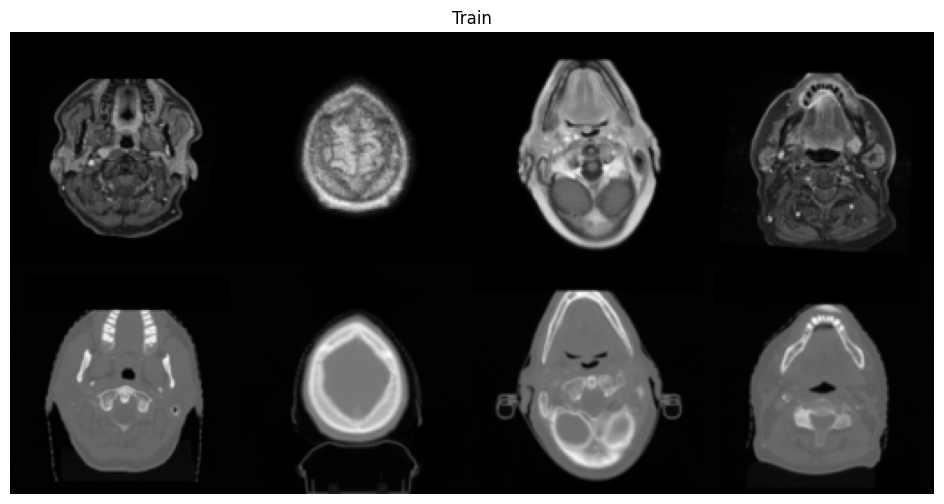

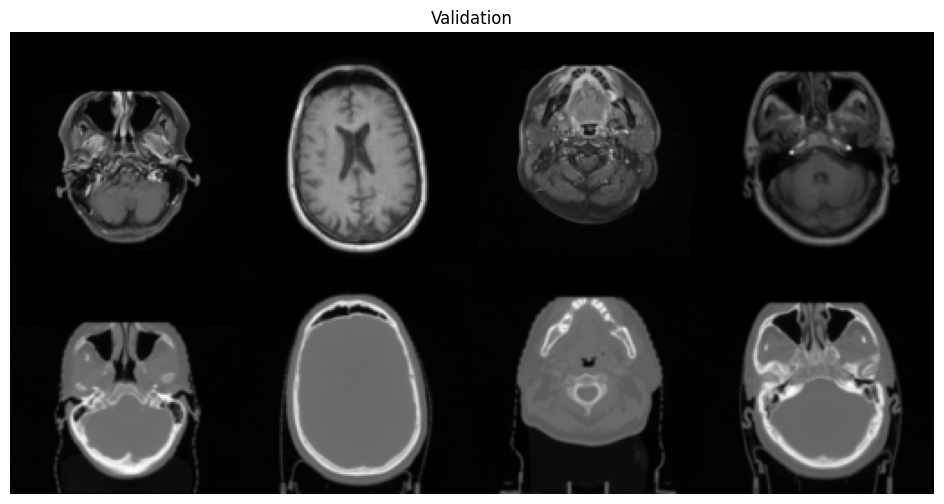

In [8]:
from torchvision import transforms
from torch.utils.data import DataLoader, Subset


# Custom dataset
class MedicalImageDataset(Dataset):
    def __init__(self, x_list, y_list, transform=None):
        assert len(x_list) == len(y_list), "x and y must have the same length"
        self.x_list = x_list
        self.y_list = y_list

    def __len__(self):
        return len(self.x_list)

    def __getitem__(self, idx):
        x = self.x_list[idx]
        y = self.y_list[idx]

        return x, y


def load_transformed_dataset():
    data_transforms = [
        transforms.Grayscale(num_output_channels=1),  # convert to grayscale
        transforms.Resize((128, 128)),
        #transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Lambda(lambda t: (t * 2) - 1)  # scale to [-1, 1]
    ]
    return transforms.Compose(data_transforms)



def plot_images(images_x, images_y, title):
    plt.figure(figsize=(16, 6))
    plt.imshow(torch.cat([torch.cat([i for i in images_x], dim=-1),
                          torch.cat([i for i in images_y], dim=-1)], dim=-2).permute(1, 2, 0).cpu(), cmap='gray')
    plt.axis('off')
    plt.title(title)
    plt.show()


BATCH_SIZE = 4
VAL_SPLIT = 0.2

print(len(MRI_images))

transform = load_transformed_dataset()

transformed_data_MRI = [transform(img) for img in MRI_images]
transformed_data_CT = [transform(img) for img in CT_images]

# Full dataset
full_dataset = MedicalImageDataset(transformed_data_MRI, transformed_data_CT)

# Sequential split: first 80% train, last 20% validation
dataset_size = len(full_dataset)
split_idx = int(dataset_size * (1 - VAL_SPLIT))

train_dataset = Subset(full_dataset, range(0, split_idx))
val_dataset = Subset(full_dataset, range(split_idx, dataset_size))

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,      # shuffle only during training
    drop_last=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    drop_last=False
)

print(f"Training samples: {len(train_dataset)}")
print(f"Validation samples: {len(val_dataset)}")

# Visualize
batch_x, batch_y = next(iter(train_loader))
plot_images(batch_x[:8], batch_y[:8], title='Train')

batch_x_val, batch_y_val = next(iter(val_loader))
plot_images(batch_x_val[:8], batch_y_val[:8], title='Validation')


In [ ]:
for i in range(20):
  print(torch.max(next(iter(train_loader))[0]), torch.min(next(iter(train_loader))[0]))

tensor(0.8353) tensor(-1.)
tensor(0.9216) tensor(-1.)
tensor(0.9451) tensor(-1.)
tensor(0.9451) tensor(-1.)
tensor(0.7333) tensor(-1.)
tensor(0.8510) tensor(-1.)
tensor(0.9216) tensor(-1.)
tensor(0.9451) tensor(-1.)
tensor(0.7647) tensor(-1.)
tensor(0.8902) tensor(-1.)
tensor(0.8510) tensor(-1.)
tensor(0.9294) tensor(-1.)
tensor(0.9294) tensor(-1.)
tensor(0.9451) tensor(-1.)
tensor(0.8902) tensor(-1.)
tensor(0.8588) tensor(-1.)
tensor(0.8353) tensor(-1.)
tensor(0.8980) tensor(-1.)
tensor(0.9373) tensor(-1.)
tensor(0.8353) tensor(-1.)


In [20]:
yaml_path = "/content/config/medical_image.yaml"

# Example content to write
yaml_content = f"""
dataset_params:
  im_path: '/content/data/medical_image_data'
  im_channels : 1
  im_size : 32
  name: 'medical_image'

diffusion_params:
  num_timesteps : 1000
  beta_start : 0.0015
  beta_end : 0.0195

ldm_params:
  down_channels: [ 256, 384, 512, 768 ]
  mid_channels: [ 768, 512 ]
  down_sample: [ True, True, True ]
  attn_down : [True, True, True]
  time_emb_dim: 512
  norm_channels: 32
  num_heads: 16
  conv_out_channels : 128
  num_down_layers : 2
  num_mid_layers : 2
  num_up_layers : 2

autoencoder_params:
  z_channels: 4
  codebook_size : 8192
  down_channels : [64, 128, 256, 256]
  mid_channels : [256, 256]
  down_sample : [True, True, False]
  attn_down : [False, False, False]
  norm_channels: 32
  num_heads: 4
  num_down_layers : 2
  num_mid_layers : 2
  num_up_layers : 2

train_params:
  seed : 1111
  task_name: 'MRI_to_CT'
  ldm_batch_size: {BATCH_SIZE}
  autoencoder_batch_size: 4
  disc_start: 15000
  disc_weight: 0.5
  codebook_weight: 1
  commitment_beta: 0.2
  perceptual_weight: 1
  kl_weight: 0.000005
  ldm_epochs: 100
  autoencoder_epochs: 20
  num_samples: {BATCH_SIZE}
  num_grid_rows: 4
  ldm_lr: 0.000005
  autoencoder_lr: 0.00001
  autoencoder_acc_steps: 4
  autoencoder_img_save_steps: 64
  save_latents : False
  vae_latent_dir_name: 'vae_latents'
  vqvae_latent_dir_name: 'vqvae_latents'
  ldm_ckpt_name: 'ddpm_ckpt.pth'
  vqvae_autoencoder_ckpt_name: 'vqvae_autoencoder_ckpt.pth'
  vae_autoencoder_ckpt_name: 'vae_autoencoder_ckpt.pth'
  vqvae_discriminator_ckpt_name: 'vqvae_discriminator_ckpt.pth'
  vae_discriminator_ckpt_name: 'vae_discriminator_ckpt.pth'

"""

# Overwrite the file
with open(yaml_path, "w") as f:
    f.write(yaml_content)


In [10]:
import torch.nn.functional as F

def down_sample_img(x):

  # 2. Downsample by 2 (nearest neighbor for simplicity)
  x_ds = F.interpolate(x, scale_factor=0.5, mode='nearest')  # [8,1,128,128]

  # 3. Extract 2x2 patches
  patches = x_ds.unfold(2, 2, 2).unfold(3, 2, 2)  # [8,1,64,64,2,2]

  # 4. Pick 3 pixels from each 2x2 block
  # Example: top-left, top-right, bottom-left
  sel = torch.stack([
      patches[..., 0, 0],  # (8,1,64,64)
      patches[..., 0, 1],  # (8,1,64,64)
      patches[..., 1, 0],   # (8,1,64,64)
      patches[..., 1, 1]
  ], dim=1).squeeze()  # [8,3,64,64]

  # sel = patches[..., 0, 0]

  return sel

In [11]:
import torch
import torch.nn as nn
import torch.nn.functional as F

from models.blocks import get_time_embedding
from models.blocks import DownBlock, MidBlock, UpBlockUnet


class Unet(nn.Module):
    r"""
    Conditional U-Net using:
      1. Concatenation of noisy CT and MRI latents at the input.
      2. Cross-attention with the MRI latent at the bottleneck.
    """

    def __init__(self, im_channels, model_config):
        super().__init__()

        self.im_channels = im_channels  # NEW

        self.down_channels = model_config['down_channels']
        self.mid_channels = model_config['mid_channels']
        self.t_emb_dim = model_config['time_emb_dim']
        self.down_sample = model_config['down_sample']
        self.num_down_layers = model_config['num_down_layers']
        self.num_mid_layers = model_config['num_mid_layers']
        self.num_up_layers = model_config['num_up_layers']
        self.attns = model_config['attn_down']
        self.norm_channels = model_config['norm_channels']
        self.num_heads = model_config['num_heads']
        self.conv_out_channels = model_config['conv_out_channels']

        assert self.mid_channels[0] == self.down_channels[-1]
        assert self.mid_channels[-1] == self.down_channels[-2]
        assert len(self.down_sample) == len(self.down_channels) - 1
        assert len(self.attns) == len(self.down_channels) - 1

        bottleneck_channels = self.down_channels[-1]  # NEW

        assert bottleneck_channels % self.num_heads == 0, (
            f"Bottleneck channels ({bottleneck_channels}) must be divisible "
            f"by num_heads ({self.num_heads})."
        )

        # Time embedding
        self.t_proj = nn.Sequential(
            nn.Linear(self.t_emb_dim, self.t_emb_dim),
            nn.SiLU(),
            nn.Linear(self.t_emb_dim, self.t_emb_dim)
        )

        self.up_sample = list(reversed(self.down_sample))

        # Existing early concatenation:
        # [noisy CT latent, MRI latent]
        self.conv_in = nn.Conv2d(
            2 * im_channels,
            self.down_channels[0],
            kernel_size=3,
            padding=1
        )

        self.downs = nn.ModuleList([])

        for i in range(len(self.down_channels) - 1):
            self.downs.append(
                DownBlock(
                    self.down_channels[i],
                    self.down_channels[i + 1],
                    self.t_emb_dim,
                    down_sample=self.down_sample[i],
                    num_heads=self.num_heads,
                    num_layers=self.num_down_layers,
                    attn=self.attns[i],
                    norm_channels=self.norm_channels
                )
            )

        # ---------------------------------------------------------
        # NEW: MRI projection and bottleneck cross-attention
        # ---------------------------------------------------------
        self.mri_context_projection = nn.Conv2d(
            im_channels,
            bottleneck_channels,
            kernel_size=1
        )

        self.cross_attention_norm = nn.LayerNorm(
            bottleneck_channels
        )

        self.mri_context_norm = nn.LayerNorm(
            bottleneck_channels
        )

        self.cross_attention = nn.MultiheadAttention(
            embed_dim=bottleneck_channels,
            num_heads=self.num_heads,
            batch_first=True
        )
        # ---------------------------------------------------------

        self.mids = nn.ModuleList([])

        for i in range(len(self.mid_channels) - 1):
            self.mids.append(
                MidBlock(
                    self.mid_channels[i],
                    self.mid_channels[i + 1],
                    self.t_emb_dim,
                    num_heads=self.num_heads,
                    num_layers=self.num_mid_layers,
                    norm_channels=self.norm_channels
                )
            )

        self.ups = nn.ModuleList([])

        for i in reversed(range(len(self.down_channels) - 1)):
            self.ups.append(
                UpBlockUnet(
                    self.down_channels[i] * 2,
                    (
                        self.down_channels[i - 1]
                        if i != 0
                        else self.conv_out_channels
                    ),
                    self.t_emb_dim,
                    up_sample=self.down_sample[i],
                    num_heads=self.num_heads,
                    num_layers=self.num_up_layers,
                    norm_channels=self.norm_channels
                )
            )

        self.norm_out = nn.GroupNorm(
            self.norm_channels,
            self.conv_out_channels
        )

        self.conv_out = nn.Conv2d(
            self.conv_out_channels,
            im_channels,
            kernel_size=3,
            padding=1
        )

    def apply_mri_cross_attention(self, out, mri_condition):
        """
        out:
            Bottleneck CT features [B, C_b, H_b, W_b]

        mri_condition:
            Original MRI latent [B, C_z, H_z, W_z]
        """

        batch_size, channels, height, width = out.shape

        # Match MRI spatial resolution to the CT bottleneck
        mri_context = F.interpolate(
            mri_condition,
            size=(height, width),
            mode='bilinear',
            align_corners=False
        )

        # Match MRI channels to bottleneck channels
        mri_context = self.mri_context_projection(mri_context)

        # [B, C, H, W] -> [B, H*W, C]
        ct_tokens = out.flatten(2).transpose(1, 2)
        mri_tokens = mri_context.flatten(2).transpose(1, 2)

        # Pre-normalization
        query = self.cross_attention_norm(ct_tokens)
        context = self.mri_context_norm(mri_tokens)

        attended_features, _ = self.cross_attention(
            query=query,
            key=context,
            value=context,
            need_weights=False
        )

        # Residual connection
        ct_tokens = ct_tokens + attended_features

        # [B, H*W, C] -> [B, C, H, W]
        out = ct_tokens.transpose(1, 2).reshape(
            batch_size,
            channels,
            height,
            width
        )

        return out

    def forward(self, x, t, mri_condition):
        """
        x:
            Concatenated noisy CT and MRI latents:
            [B, 2*z_channels, H, W]

        mri_condition:
            MRI latent alone:
            [B, z_channels, H, W]
        """

        # Early conditioning through concatenation
        out = self.conv_in(x)

        t = torch.as_tensor(t, device=x.device).long()

        # Ensure one timestep per batch item
        if t.ndim == 0:
            t = t.repeat(x.shape[0])
        elif t.numel() == 1 and x.shape[0] > 1:
            t = t.repeat(x.shape[0])

        t_emb = get_time_embedding(t, self.t_emb_dim)
        t_emb = self.t_proj(t_emb)

        down_outs = []

        for down in self.downs:
            down_outs.append(out)
            out = down(out, t_emb)

        # NEW: bottleneck cross-attention with MRI
        out = self.apply_mri_cross_attention(
            out,
            mri_condition
        )

        for mid in self.mids:
            out = mid(out, t_emb)

        for up in self.ups:
            down_out = down_outs.pop()
            out = up(out, down_out, t_emb)

        out = self.norm_out(out)
        out = F.silu(out)
        out = self.conv_out(out)

        return out

In [12]:
import torch
import torch.nn as nn
from models.blocks import DownBlock, MidBlock, UpBlock


class VQVAE(nn.Module):
    def __init__(self, im_channels, model_config):
        super().__init__()
        self.down_channels = model_config['down_channels']
        self.mid_channels = model_config['mid_channels']
        self.down_sample = model_config['down_sample']
        self.num_down_layers = model_config['num_down_layers']
        self.num_mid_layers = model_config['num_mid_layers']
        self.num_up_layers = model_config['num_up_layers']

        # To disable attention in Downblock of Encoder and Upblock of Decoder
        self.attns = model_config['attn_down']

        # Latent Dimension
        self.z_channels = model_config['z_channels']
        self.codebook_size = model_config['codebook_size']
        self.norm_channels = model_config['norm_channels']
        self.num_heads = model_config['num_heads']

        # Assertion to validate the channel information
        assert self.mid_channels[0] == self.down_channels[-1]
        assert self.mid_channels[-1] == self.down_channels[-1]
        assert len(self.down_sample) == len(self.down_channels) - 1
        assert len(self.attns) == len(self.down_channels) - 1

        # Wherever we use downsampling in encoder correspondingly use
        # upsampling in decoder
        self.up_sample = list(reversed(self.down_sample))

        ##################### Encoder ######################
        self.encoder_conv_in = nn.Conv2d(im_channels, self.down_channels[0], kernel_size=3, padding=(1, 1))

        # Downblock + Midblock
        self.encoder_layers = nn.ModuleList([])
        for i in range(len(self.down_channels) - 1):
            self.encoder_layers.append(DownBlock(self.down_channels[i], self.down_channels[i + 1],
                                                 t_emb_dim=None, down_sample=self.down_sample[i],
                                                 num_heads=self.num_heads,
                                                 num_layers=self.num_down_layers,
                                                 attn=self.attns[i],
                                                 norm_channels=self.norm_channels))

        self.encoder_mids = nn.ModuleList([])
        for i in range(len(self.mid_channels) - 1):
            self.encoder_mids.append(MidBlock(self.mid_channels[i], self.mid_channels[i + 1],
                                              t_emb_dim=None,
                                              num_heads=self.num_heads,
                                              num_layers=self.num_mid_layers,
                                              norm_channels=self.norm_channels))

        self.encoder_norm_out = nn.GroupNorm(self.norm_channels, self.down_channels[-1])
        self.encoder_conv_out = nn.Conv2d(self.down_channels[-1], self.z_channels, kernel_size=3, padding=1)

        # Pre Quantization Convolution
        self.pre_quant_conv = nn.Conv2d(self.z_channels, self.z_channels, kernel_size=1)

        # Codebook
        self.embedding = nn.Embedding(self.codebook_size, self.z_channels)
        ####################################################

        ##################### Decoder ######################

        # Post Quantization Convolution
        self.post_quant_conv = nn.Conv2d(self.z_channels*2, self.z_channels, kernel_size=1)
        self.decoder_conv_in = nn.Conv2d(self.z_channels*2, self.mid_channels[-1], kernel_size=3, padding=(1, 1))

        # Midblock + Upblock
        self.decoder_mids = nn.ModuleList([])
        for i in reversed(range(1, len(self.mid_channels))):
            self.decoder_mids.append(MidBlock(self.mid_channels[i]*2, self.mid_channels[i - 1],
                                              t_emb_dim=None,
                                              num_heads=self.num_heads,
                                              num_layers=self.num_mid_layers,
                                              norm_channels=self.norm_channels))

        self.decoder_layers = nn.ModuleList([])
        for i in reversed(range(1, len(self.down_channels))):
            self.decoder_layers.append(UpBlock(self.down_channels[i]*2, self.down_channels[i - 1],
                                               t_emb_dim=None, up_sample=self.down_sample[i - 1],
                                               num_heads=self.num_heads,
                                               num_layers=self.num_up_layers,
                                               attn=self.attns[i-1],
                                               norm_channels=self.norm_channels))

        self.decoder_norm_out = nn.GroupNorm(self.norm_channels, self.down_channels[0])
        self.decoder_conv_out = nn.Conv2d(2*self.down_channels[0], im_channels, kernel_size=3, padding=1)

    def quantize(self, x):
        B, C, H, W = x.shape

        # B, C, H, W -> B, H, W, C
        x = x.permute(0, 2, 3, 1)

        # B, H, W, C -> B, H*W, C
        x = x.reshape(x.size(0), -1, x.size(-1))

        # Find nearest embedding/codebook vector
        # dist between (B, H*W, C) and (B, K, C) -> (B, H*W, K)
        dist = torch.cdist(x, self.embedding.weight[None, :].repeat((x.size(0), 1, 1)))
        # (B, H*W)
        min_encoding_indices = torch.argmin(dist, dim=-1)

        # Replace encoder output with nearest codebook
        # quant_out -> B*H*W, C
        quant_out = torch.index_select(self.embedding.weight, 0, min_encoding_indices.view(-1))

        # x -> B*H*W, C
        x = x.reshape((-1, x.size(-1)))
        commmitment_loss = torch.mean((quant_out.detach() - x) ** 2)
        codebook_loss = torch.mean((quant_out - x.detach()) ** 2)
        quantize_losses = {
            'codebook_loss': codebook_loss,
            'commitment_loss': commmitment_loss
        }
        # Straight through estimation
        quant_out = x + (quant_out - x).detach()

        # quant_out -> B, C, H, W
        quant_out = quant_out.reshape((B, H, W, C)).permute(0, 3, 1, 2)
        min_encoding_indices = min_encoding_indices.reshape((-1, quant_out.size(-2), quant_out.size(-1)))
        return quant_out, quantize_losses, min_encoding_indices

    def encode(self, x):

        out = self.encoder_conv_in(x)
        y = [out]

        #print(len(y), 'y')

        for idx, down in enumerate(self.encoder_layers):
            out = down(out)
            y.append(out)
        for mid in self.encoder_mids:
            out = mid(out)
            y.append(out)

        out = self.encoder_norm_out(out)
        out = nn.SiLU()(out)
        out = self.encoder_conv_out(out)
        y.append(out)
        out = self.pre_quant_conv(out)
        y.append(out)
        out, quant_losses, _ = self.quantize(out)

        #print(len(y), 'y')

        return out, y, quant_losses

    def decode(self, z, y):
        out = z

        out = self.post_quant_conv(torch.cat((out, y[-1]), 1))

        out = self.decoder_conv_in(torch.cat((out, y[-2]), 1))
        for idx, mid in  enumerate(self.decoder_mids):
            out = mid(torch.cat((out, y[-3-idx]), 1))
        for idx, up in enumerate(self.decoder_layers):
            out = up(torch.cat((out, y[-3-len(self.decoder_mids)-idx]), 1))

        out = self.decoder_norm_out(out)
        out = nn.SiLU()(out)
        out = self.decoder_conv_out(torch.cat((out, y[0]), 1))
        #out = self.decoder_conv_out(out)
        return out

    #def forward(self, x):
     #   pass
        #return out, z, quant_losses



class XVQ_VAE(nn.Module):
    def __init__(self, im_channels, model_config):
        super().__init__()

        self.vae1 = VQVAE(im_channels=im_channels,
                  model_config=model_config)

        self.vae2 = VQVAE(im_channels=im_channels,
                  model_config=model_config)


    def dropout_condition(self, cond, drop_prob=0.1):
          if not self.training:  # only drop during training
              return cond

          # With prob=drop_prob, replace the condition with zeros
          if torch.rand(1).item() < drop_prob:
              cond_zero = []
              for i in range(len(cond)):
                cond_zero.append(torch.zeros_like(cond[i]))
                return cond_zero
          return cond

    """
    def encode1(self, x1):
          out1 = self.vae1.encode(x1)
          #print(len(out1))
          return out1

    def encode2(self, x2):
          out2 = self.vae2.encode(x2)
          #print(len(out2))
          return out2

    def decode1(self, z1, y2_drop):
          out1 = self.vae1.decode(z1, y2_drop)
          return out1

    def decode2(self, z2, y1_drop):
          out2 = self.vae2.decode(z2, y1_drop)
          return out2
    """

    def forward(self, x1, x2):

          #print(len(out0))
          out1 = self.vae1.encode(x1)
          out2 = self.vae2.encode(x2)

          #print(len(out1), len(out2))
          #print(type(out1[0]), type(out1[1]), type(out1[-1]))

          z1, y1, quant_losses1 = out1
          z2, y2, quant_losses2 = out2

          #print(z1.shape)

          y1_drop = self.dropout_condition(y1)
          y2_drop = self.dropout_condition(y2)

          #y1_drop = self.dropout_condition(y1)
          #y2_drop = self.dropout_condition(y2)

          out1 = self.vae1.decode(z1, y2)
          out2 = self.vae2.decode(z2, y1)

          return out1, out2, z1, z2, quant_losses1, quant_losses2

In [13]:
import torch
import yaml
import argparse
import os
import numpy as np
from tqdm import tqdm
from torch.optim import Adam
from torch.utils.data import DataLoader
#from models.unet_base import Unet
#from models.vqvae import VQVAE
from scheduler.linear_noise_scheduler import LinearNoiseScheduler

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')


def train(args, data_loader):
    # Read the config file #
    with open(args.config_path, 'r') as file:
        try:
            config = yaml.safe_load(file)
        except yaml.YAMLError as exc:
            print(exc)
    print(config)
    ########################

    diffusion_config = config['diffusion_params']
    dataset_config = config['dataset_params']
    diffusion_model_config = config['ldm_params']
    autoencoder_model_config = config['autoencoder_params']
    train_config = config['train_params']

    # Create the noise scheduler
    scheduler = LinearNoiseScheduler(num_timesteps=diffusion_config['num_timesteps'],
                                     beta_start=diffusion_config['beta_start'],
                                     beta_end=diffusion_config['beta_end'])


    """
    im_dataset = im_dataset_cls(split='train',
                                im_path=dataset_config['im_path'],
                                im_size=dataset_config['im_size'],
                                im_channels=dataset_config['im_channels'],
                                use_latents=True,
                                latent_path=os.path.join(train_config['task_name'],
                                                         train_config['vqvae_latent_dir_name'])
                                )
    """

    #data_loader = DataLoader(im_dataset,
    #                         batch_size=train_config['ldm_batch_size'],
    #                         shuffle=True)


    # Instantiate the model
    model = Unet(im_channels=autoencoder_model_config['z_channels'],
                 model_config=diffusion_model_config).to(device)

    model.load_state_dict(torch.load('/content/drive/MyDrive/Medical_Image/ddpm_mri_ct_ckpt.pth',
                                       map_location=device))
    model.train()

    # Load VAE ONLY if latents are not to be used or are missing
    if True:#not im_dataset.use_latents:
        print('Loading vqvae model as latents not present')
        vae = XVQ_VAE(im_channels=dataset_config['im_channels'],
                    model_config=autoencoder_model_config).to(device)

        # Load vae if found
        #if os.path.exists(os.path.join(train_config['task_name'],
        #                                train_config['vqvae_autoencoder_ckpt_name'])):
        #    print('Loaded vae checkpoint')
        vae.load_state_dict(torch.load('/content/drive/MyDrive/Medical_Image/vae.pth',
                                       map_location=device))
        vae.eval()

    # Specify training parameters
    num_epochs = 5 #train_config['ldm_epochs']
    optimizer = Adam(model.parameters(), lr=train_config['ldm_lr'])
    criterion = torch.nn.MSELoss()

    # Run training
    if True: #not im_dataset.use_latents:
        for param in vae.parameters():
            param.requires_grad = False

    for epoch_idx in range(num_epochs):
        losses = []
        for im_x, im in tqdm(data_loader):
            optimizer.zero_grad()

            im = im.float().to(device)
            im_x = im_x.float().to(device)

            if True:#not im_dataset.use_latents:
                with torch.no_grad():
                    im_x, _, _ = vae.vae1.encode(im_x)
                    im, _, _ = vae.vae2.encode(im)


            #im = down_sample_img(im)
            #im_x = down_sample_img(im_x)

            # Sample random noise
            noise = torch.randn_like(im).to(device)

            # Sample timestep
            t = torch.randint(0, diffusion_config['num_timesteps'], (im.shape[0],)).to(device)

            # Add noise to images according to timestep
            noisy_im = scheduler.add_noise(im, noise, t)

            model_input = torch.cat(
                (noisy_im, im_x),
                dim=1
            )

            noise_pred = model(
                model_input,
                t,
                mri_condition=im_x
            )

            loss = criterion(noise_pred, noise)
            losses.append(loss.item())
            loss.backward()
            optimizer.step()
        print('Finished epoch:{} | Loss : {:.4f}'.format(
            epoch_idx + 1,
            np.mean(losses)))

        torch.save(model.state_dict(), '/content/drive/MyDrive/Medical_Image/ddpm_mri_ct_ckpt.pth')

    print('Done Training ...')
    return model




In [ ]:
import argparse
import sys

parser = argparse.ArgumentParser(description='Arguments for ddpm training')
parser.add_argument('--config', dest='config_path', default='/content/config/medical_image.yaml', type=str)

# Filter out unrecognized arguments from sys.argv
args, unknown = parser.parse_known_args(sys.argv[1:])

model = train(args, train_loader)

{'dataset_params': {'im_path': '/content/data/medical_image_data', 'im_channels': 1, 'im_size': 32, 'name': 'medical_image'}, 'diffusion_params': {'num_timesteps': 1000, 'beta_start': 0.0015, 'beta_end': 0.0195}, 'ldm_params': {'down_channels': [256, 384, 512, 768], 'mid_channels': [768, 512], 'down_sample': [True, True, True], 'attn_down': [True, True, True], 'time_emb_dim': 512, 'norm_channels': 32, 'num_heads': 16, 'conv_out_channels': 128, 'num_down_layers': 2, 'num_mid_layers': 2, 'num_up_layers': 2}, 'autoencoder_params': {'z_channels': 4, 'codebook_size': 8192, 'down_channels': [64, 128, 256, 256], 'mid_channels': [256, 256], 'down_sample': [True, True, False], 'attn_down': [False, False, False], 'norm_channels': 32, 'num_heads': 4, 'num_down_layers': 2, 'num_mid_layers': 2, 'num_up_layers': 2}, 'train_params': {'seed': 1111, 'task_name': 'mnist', 'ldm_batch_size': 4, 'autoencoder_batch_size': 4, 'disc_start': 15000, 'disc_weight': 0.5, 'codebook_weight': 1, 'commitment_beta': 0

KeyboardInterrupt: 

In [14]:
import torch
import torchvision
import argparse
import sys
import yaml
import os
from torchvision.utils import make_grid
from PIL import Image
from tqdm import tqdm
#from models.unet_base import Unet
#from models.vqvae import VQVAE
from scheduler.linear_noise_scheduler import LinearNoiseScheduler
from PIL import Image, ImageDraw, ImageFont
import os
import torch
import torchvision
from torchvision.utils import make_grid

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

try:
    os.mkdir('/content/results')
except OSError as e:
    print("Error:", e)


def sample(model, vae, val_loader, scheduler, train_config, diffusion_model_config,
               autoencoder_model_config, diffusion_config, dataset_config):
    r"""
    Sample stepwise by going backward one timestep at a time.
    We save the x0 predictions
    """
    #im_size = dataset_config['im_size'] // 2**sum(autoencoder_model_config['down_sample'])
    im_x_org, im_y_org = next(iter(val_loader))

    im_x_org = im_x_org.to(device)
    im_y_org = im_y_org.to(device)

    im_x, y1, _ = vae.vae1.encode(im_x_org)
    im_y, y2, _ = vae.vae2.encode(im_y_org)

    # Match the actual CT latent shape exactly
    xt = torch.randn_like(im_y)


    save_count = 0

    for i in tqdm(reversed(range(diffusion_config['num_timesteps']))):
        # Get prediction of noise

        t = torch.full(
            (xt.shape[0],),
            i,
            device=device,
            dtype=torch.long
        )

        model_input = torch.cat(
            (xt, im_x),
            dim=1
        )

        noise_pred = model(
            model_input,
            t,
            mri_condition=im_x
        )

        # Use scheduler to get x0 and xt-1
        xt, x0_pred = scheduler.sample_prev_timestep(xt, noise_pred, torch.as_tensor(i).to(device))

        # Save x0
        if i == 0:
            ims = torch.cat((
                im_y_org.to(device),           # CT ground truth
                vae.vae2.decode(xt, y1),       # CT predicted
                im_x_org.to(device)            # MRI input
            ), dim=0)
        else:
            ims = torch.cat((
                im_y,
                xt,
                im_x
            ), dim=0)[:, 0, :, :].unsqueeze(1)

        ims = torch.clamp(ims, -1., 1.).detach().cpu()
        ims = (ims + 1) / 2

        nrow = train_config['num_grid_rows']
        grid = make_grid(ims, nrow=nrow)

        img = torchvision.transforms.ToPILImage()(grid)

        if i == 0:
            # Decode ONLY the final iamge to save time
            #ims = vae.decode(xt, y1)
            ims = torch.cat((im_y_org.to(device), vae.vae2.decode(xt, y1), im_x_org.to(device)), dim=0)
        else:
            ims = torch.cat((im_y, xt, im_x), dim=0)[:, 0, :, :].unsqueeze(1)
            #ims = torch.cat((im_y_org.to(device), vae.vae2.decode(xt, y1), im_x_org.to(device)), dim=0)


        ims = torch.clamp(ims, -1., 1.).detach().cpu()
        ims = (ims + 1) / 2
        grid = make_grid(ims, nrow=train_config['num_grid_rows'])

        img = torchvision.transforms.ToPILImage()(grid)

        if not os.path.exists(os.path.join('/content/results', 'samples')):
            os.mkdir(os.path.join('/content/results', 'samples'))
        img.save(os.path.join('/content/results', 'samples', 'x0_{}.png'.format(i)))
        img.close()


def infer(args, model, vae, val_loader):
    # Read the config file #
    with open(args.config_path, 'r') as file:
        try:
            config = yaml.safe_load(file)
        except yaml.YAMLError as exc:
            print(exc)
    print(config)
    ########################

    diffusion_config = config['diffusion_params']
    dataset_config = config['dataset_params']
    diffusion_model_config = config['ldm_params']
    autoencoder_model_config = config['autoencoder_params']
    train_config = config['train_params']

    # Create the noise scheduler
    scheduler = LinearNoiseScheduler(num_timesteps=diffusion_config['num_timesteps'],
                                     beta_start=diffusion_config['beta_start'],
                                     beta_end=diffusion_config['beta_end'])

    #model = Unet(im_channels=autoencoder_model_config['z_channels'],
     #            model_config=diffusion_model_config).to(device)
    #model.eval()
    #if os.path.exists(os.path.join(train_config['task_name'],
     #                              train_config['ldm_ckpt_name'])):
      #  print('Loaded unet checkpoint')
     #   model.load_state_dict(torch.load(os.path.join(train_config['task_name'],
      #                                                train_config['ldm_ckpt_name']),
      #                                   map_location=device))

    # Create output directories
    if not os.path.exists(train_config['task_name']):
        os.mkdir(train_config['task_name'])


    with torch.no_grad():
        sample(model, vae, val_loader, scheduler, train_config, diffusion_model_config,
               autoencoder_model_config, diffusion_config, dataset_config)



parser = argparse.ArgumentParser(description='Arguments for ddpm image generation')
parser.add_argument('--config', dest='config_path',
                    default='/content/config/medical_image.yaml', type=str)

args, unknown = parser.parse_known_args(sys.argv[1:])


with open(args.config_path, 'r') as file:
        try:
            config = yaml.safe_load(file)
        except yaml.YAMLError as exc:
            print(exc)
        print(config)
        ########################

        diffusion_config = config['diffusion_params']
        dataset_config = config['dataset_params']
        diffusion_model_config = config['ldm_params']
        autoencoder_model_config = config['autoencoder_params']
        train_config = config['train_params']


model = Unet(im_channels=autoencoder_model_config['z_channels'],
                 model_config=diffusion_model_config).to(device)
model.load_state_dict(torch.load('/content/drive/MyDrive/Medical_Image/ddpm_mri_ct_ckpt.pth',
                                       map_location=device))
print(1)
model.eval()

# Load VAE ONLY if latents are not to be used or are missing
if True:#not im_dataset.use_latents:
    print('Loading vqvae model as latents not present')
    vae = XVQ_VAE(im_channels=dataset_config['im_channels'],
                model_config=autoencoder_model_config).to(device)

    # Load vae if found
    #if os.path.exists(os.path.join(train_config['task_name'],
    #                                train_config['vqvae_autoencoder_ckpt_name'])):
    #    print('Loaded vae checkpoint')
    vae.load_state_dict(torch.load('/content/drive/MyDrive/Medical_Image/vae.pth',
                                    map_location=device))
    vae.eval()
    print(2)

infer(args, model, vae, val_loader=val_loader)

{'dataset_params': {'im_path': '/content/data/medical_image_data', 'im_channels': 1, 'im_size': 32, 'name': 'medical_image'}, 'diffusion_params': {'num_timesteps': 1000, 'beta_start': 0.0015, 'beta_end': 0.0195}, 'ldm_params': {'down_channels': [256, 384, 512, 768], 'mid_channels': [768, 512], 'down_sample': [True, True, True], 'attn_down': [True, True, True], 'time_emb_dim': 512, 'norm_channels': 32, 'num_heads': 16, 'conv_out_channels': 128, 'num_down_layers': 2, 'num_mid_layers': 2, 'num_up_layers': 2}, 'autoencoder_params': {'z_channels': 4, 'codebook_size': 8192, 'down_channels': [64, 128, 256, 256], 'mid_channels': [256, 256], 'down_sample': [True, True, False], 'attn_down': [False, False, False], 'norm_channels': 32, 'num_heads': 4, 'num_down_layers': 2, 'num_mid_layers': 2, 'num_up_layers': 2}, 'train_params': {'seed': 1111, 'task_name': 'mnist', 'ldm_batch_size': 4, 'autoencoder_batch_size': 4, 'disc_start': 15000, 'disc_weight': 0.5, 'codebook_weight': 1, 'commitment_beta': 0

1000it [01:17, 12.85it/s]


In [18]:
!zip -r /content/repo.zip /content/StableDiffusion-PyTorch
!zip -r /content/results.zip /content/results

updating: content/StableDiffusion-PyTorch/ (stored 0%)
updating: content/StableDiffusion-PyTorch/.git/ (stored 0%)
updating: content/StableDiffusion-PyTorch/.git/index (deflated 55%)
updating: content/StableDiffusion-PyTorch/.git/config (deflated 31%)
updating: content/StableDiffusion-PyTorch/.git/refs/ (stored 0%)
updating: content/StableDiffusion-PyTorch/.git/refs/tags/ (stored 0%)
updating: content/StableDiffusion-PyTorch/.git/refs/remotes/ (stored 0%)
updating: content/StableDiffusion-PyTorch/.git/refs/remotes/origin/ (stored 0%)
updating: content/StableDiffusion-PyTorch/.git/refs/remotes/origin/HEAD (stored 0%)
updating: content/StableDiffusion-PyTorch/.git/refs/heads/ (stored 0%)
updating: content/StableDiffusion-PyTorch/.git/refs/heads/main (stored 0%)
updating: content/StableDiffusion-PyTorch/.git/HEAD (stored 0%)
updating: content/StableDiffusion-PyTorch/.git/packed-refs (deflated 11%)
updating: content/StableDiffusion-PyTorch/.git/description (deflated 14%)
updating: content/